# 1D CNN Classification of CWRU Bearing Fault Size

Dataset: CWRU Bearing Data Center. Same task as the other notebooks — predict
ball-fault severity (0.007in / 0.014in / 0.021in) from the Drive End vibration
signal, this time with a 1D Convolutional Neural Network (PyTorch) trained
directly on the raw windowed signal instead of hand-crafted features.

Pipeline: load `.mat` signals -> window into 1024-sample chunks -> normalize ->
train/evaluate a 1D CNN.

## 1. Imports and configuration

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)

RANDOM_STATE = 42
WINDOW_SIZE = 1024
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("Using device:", DEVICE)

Using device: cpu


## 2. Dataset configuration

Same three files/labels as the other notebooks.

In [2]:
RAW_DIR = os.path.join("..", "raw")

FILE_LABELS = {
    "B007_1_123.mat": 0,
    "B014_1_190.mat": 1,
    "B021_1_227.mat": 2,
}

LABEL_NAMES = {
    0: "0.007 in fault",
    1: "0.014 in fault",
    2: "0.021 in fault",
}

FILE_LABELS

{'B007_1_123.mat': 0, 'B014_1_190.mat': 1, 'B021_1_227.mat': 2}

## 3. Loading signals and auto-detecting the DE_time channel

In [3]:
def load_de_signal(filepath):
    """Load a CWRU .mat file and return its Drive End (DE_time) signal as a 1-D array."""
    mat = loadmat(filepath)
    de_keys = [k for k in mat.keys() if k.endswith("DE_time")]
    if not de_keys:
        raise ValueError(f"No DE_time channel found in {filepath}")
    signal = mat[de_keys[0]].flatten()
    return signal


signals = {}
for fname, label in FILE_LABELS.items():
    path = os.path.join(RAW_DIR, fname)
    signals[fname] = load_de_signal(path)
    print(f"{fname:20s} label={label}  DE_time length={len(signals[fname])}")

B007_1_123.mat       label=0  DE_time length=487384
B014_1_190.mat       label=1  DE_time length=486224
B021_1_227.mat       label=2  DE_time length=486804


## 4. Segmenting signals into fixed-length windows

In [4]:
def window_signal(signal, window_size=WINDOW_SIZE):
    """Split a 1-D signal into non-overlapping windows of `window_size` samples."""
    n_windows = len(signal) // window_size
    trimmed = signal[: n_windows * window_size]
    return trimmed.reshape(n_windows, window_size)


windowed_signals = {}
for fname, signal in signals.items():
    windowed_signals[fname] = window_signal(signal)
    print(f"{fname:20s} -> {windowed_signals[fname].shape[0]} windows of {WINDOW_SIZE} samples")

B007_1_123.mat       -> 475 windows of 1024 samples
B014_1_190.mat       -> 474 windows of 1024 samples
B021_1_227.mat       -> 475 windows of 1024 samples


## 5. Building the raw-window dataset

Unlike the Random Forest / XGBoost notebooks, we do not hand-craft features —
each window's 1024 raw samples become the CNN's input directly, and the model
learns its own representation.

In [5]:
X_list, y_list = [], []
for fname, windows in windowed_signals.items():
    label = FILE_LABELS[fname]
    X_list.append(windows)
    y_list.extend([label] * windows.shape[0])

X = np.concatenate(X_list, axis=0).astype(np.float32)
y = np.array(y_list, dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1424, 1024)
y shape: (1424,)


## 6. Class distribution

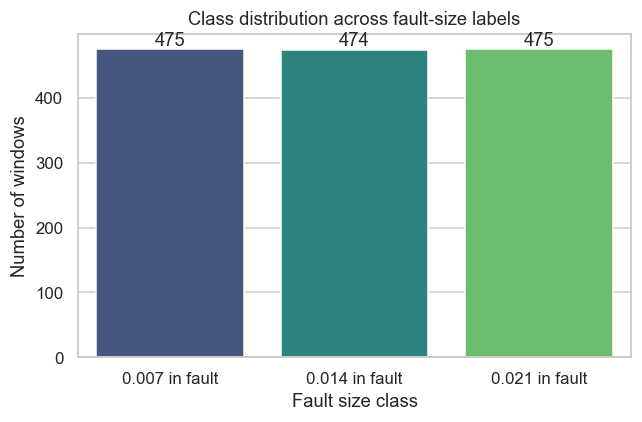

In [6]:
counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=[LABEL_NAMES[i] for i in counts.index], y=counts.values,
                  hue=[LABEL_NAMES[i] for i in counts.index], palette="viridis", legend=False)
ax.set_xlabel("Fault size class")
ax.set_ylabel("Number of windows")
ax.set_title("Class distribution across fault-size labels")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

## 7. Example raw windows per class

A quick look at one raw window from each class before normalization — larger
faults tend to show visibly higher-amplitude, more impulsive vibration.

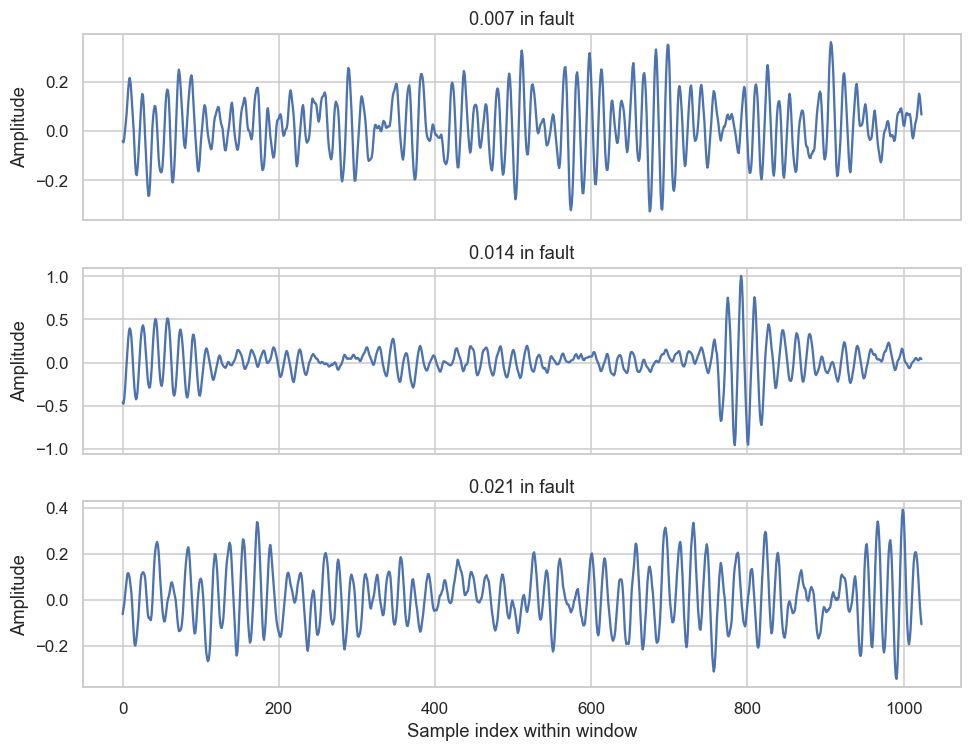

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for label, ax in zip([0, 1, 2], axes):
    idx = np.where(y == label)[0][0]
    ax.plot(X[idx])
    ax.set_title(LABEL_NAMES[label])
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Sample index within window")
plt.tight_layout()
plt.show()

## 8. Train/test split and normalization

We standardize each window (zero mean, unit variance) using statistics from
the training set only, then reshape to `(N, 1, WINDOW_SIZE)` for the CNN's
single input channel.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

train_mean, train_std = X_train.mean(), X_train.std()
X_train_norm = (X_train - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

X_train_t = torch.tensor(X_train_norm).unsqueeze(1)
X_test_t = torch.tensor(X_test_norm).unsqueeze(1)
y_train_t = torch.tensor(y_train)
y_test_t = torch.tensor(y_test)

print("Train shape:", X_train_t.shape)
print("Test shape: ", X_test_t.shape)

Train shape: torch.Size([1139, 1, 1024])
Test shape:  torch.Size([285, 1, 1024])


## 9. CNN architecture

Three Conv1d blocks (widening channels, downsampling with stride) followed by
global average pooling and a linear classifier head. Batch norm and dropout
keep training stable on this small dataset.

In [9]:
class BearingCNN(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = BearingCNN().to(DEVICE)
print(model)

BearingCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(2,), padding=(1,))
    (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=64, out_features=3, bias=True)
  )
)


## 10. Training the CNN

Adam optimizer, cross-entropy loss, 30 epochs, batch size 32. We track the
training loss and accuracy each epoch to check convergence.

In [10]:
def train_model(model, X_train_t, y_train_t, epochs=30, batch_size=32, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    history = {"loss": [], "acc": []}
    model.train()
    for epoch in range(epochs):
        total_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)

        history["loss"].append(total_loss / total)
        history["acc"].append(correct / total)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d}/{epochs}  loss={history['loss'][-1]:.4f}  acc={history['acc'][-1]:.4f}")

    return history


history = train_model(model, X_train_t, y_train_t)
print("Training complete.")

Epoch  1/30  loss=0.8591  acc=0.6910


Epoch  5/30  loss=0.1489  acc=0.9842


Epoch 10/30  loss=0.0574  acc=0.9921


Epoch 15/30  loss=0.0393  acc=0.9965


Epoch 20/30  loss=0.0350  acc=0.9947


Epoch 25/30  loss=0.0187  acc=0.9974


Epoch 30/30  loss=0.0180  acc=0.9982
Training complete.


### Training curves

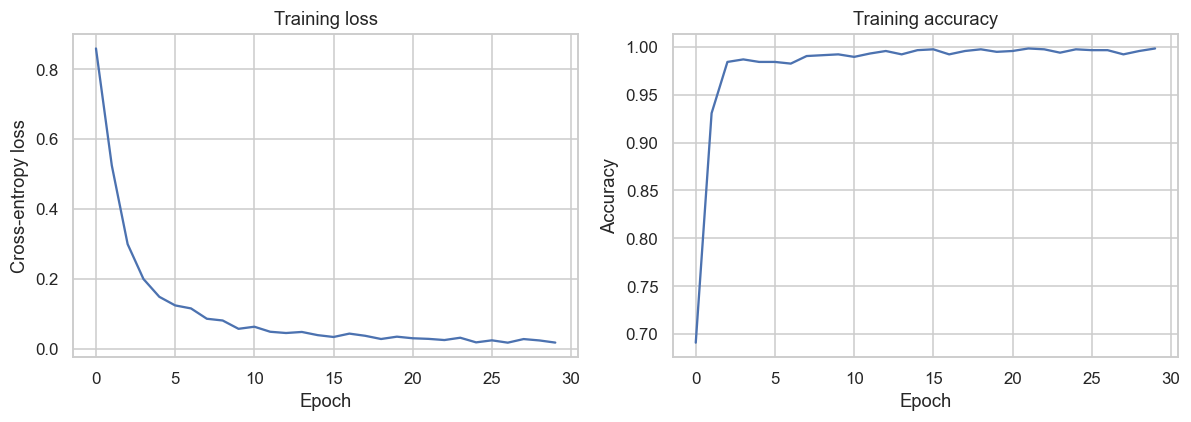

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["loss"])
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")

axes[1].plot(history["acc"])
axes[1].set_title("Training accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 11. Evaluation metrics

In [12]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(DEVICE))
    y_proba = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = y_proba.argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (macro)")
print(f"Recall   : {recall:.4f}  (macro)")
print(f"F1 Score : {f1:.4f}  (macro)")

Accuracy : 0.9965
Precision: 0.9965  (macro)
Recall   : 0.9965  (macro)
F1 Score : 0.9965  (macro)


### Classification report

In [13]:
print(classification_report(
    y_test, y_pred,
    target_names=[LABEL_NAMES[i] for i in [0, 1, 2]]
))

                precision    recall  f1-score   support

0.007 in fault       0.99      1.00      0.99        95
0.014 in fault       1.00      1.00      1.00        95
0.021 in fault       1.00      0.99      0.99        95

      accuracy                           1.00       285
     macro avg       1.00      1.00      1.00       285
  weighted avg       1.00      1.00      1.00       285



## 12. Confusion matrix

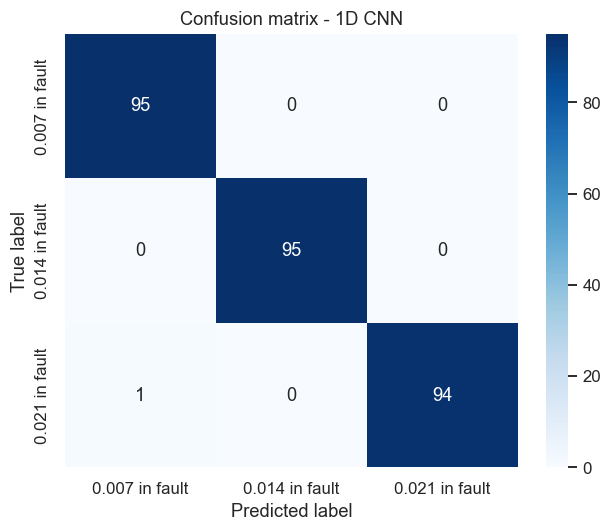

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[LABEL_NAMES[i] for i in [0, 1, 2]],
            yticklabels=[LABEL_NAMES[i] for i in [0, 1, 2]])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix - 1D CNN")
plt.tight_layout()
plt.show()

## 13. 5-Fold Cross-Validation

We retrain a fresh CNN on each fold (fewer epochs, to keep total run time
reasonable) to check that performance is stable across splits.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_norm_full = (X - train_mean) / train_std
X_full_t = torch.tensor(X_norm_full).unsqueeze(1)
y_full_t = torch.tensor(y)

cv_scores = []
for fold, (train_idx, val_idx) in enumerate(cv.split(X_norm_full, y)):
    fold_model = BearingCNN().to(DEVICE)
    train_model(fold_model, X_full_t[train_idx], y_full_t[train_idx], epochs=15)

    fold_model.eval()
    with torch.no_grad():
        val_logits = fold_model(X_full_t[val_idx].to(DEVICE))
        val_pred = val_logits.argmax(dim=1).cpu().numpy()
    fold_acc = accuracy_score(y[val_idx], val_pred)
    cv_scores.append(fold_acc)
    print(f"Fold {fold+1}: accuracy={fold_acc:.4f}")

cv_scores = np.array(cv_scores)
print(f"Mean CV accuracy: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

Epoch  1/15  loss=0.8525  acc=0.7305


Epoch  5/15  loss=0.1299  acc=0.9930


Epoch 10/15  loss=0.0489  acc=0.9947


Epoch 15/15  loss=0.0340  acc=0.9956
Fold 1: accuracy=1.0000


Epoch  1/15  loss=0.8610  acc=0.7094


...

Epoch 15/15  loss=0.0507  acc=0.9886
Fold 4: accuracy=0.9439


Epoch  1/15  loss=0.8482  acc=0.7289


Epoch  5/15  loss=0.1606  acc=0.9860


Epoch 10/15  loss=0.0536  acc=0.9956


Epoch 15/15  loss=0.0400  acc=0.9939
Fold 5: accuracy=0.9613
Mean CV accuracy: 0.9782  (+/- 0.0219)


## 14. ROC and Precision-Recall curves (one-vs-rest)

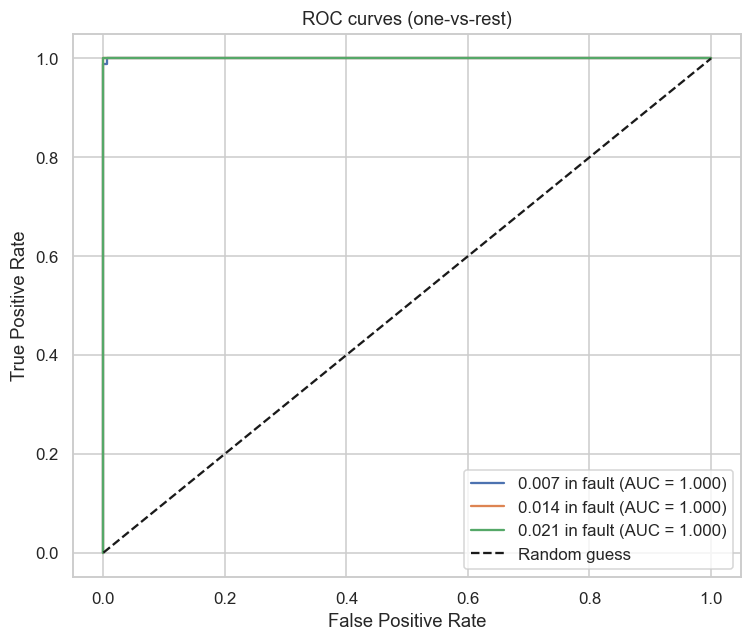

In [16]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(7, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{LABEL_NAMES[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (one-vs-rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

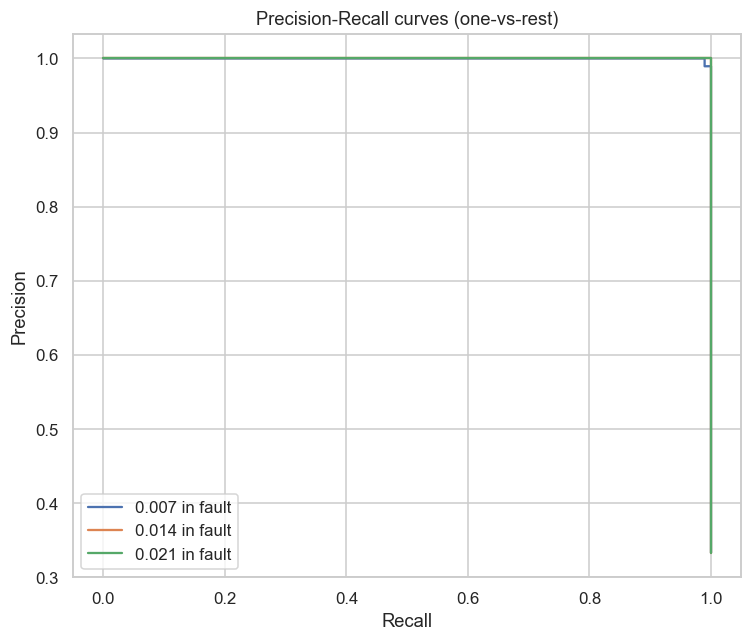

In [17]:
plt.figure(figsize=(7, 6))
for i in range(n_classes):
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(recall_curve, precision_curve, label=f"{LABEL_NAMES[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (one-vs-rest)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 15. Summary

The CNN learns directly from raw windowed signal instead of the 14
hand-crafted time-domain features used by the Random Forest / XGBoost
notebooks. Compare its accuracy/F1/CV numbers above against
`Random_Forest_CWRU.ipynb` and `XGBoost_CWRU.ipynb` — a CNN can pick up
temporal/waveform structure the hand-crafted features discard, but it needs
more data and training time to do so reliably, and is less interpretable
than the tree models' feature-importance rankings.